# 🟡 Project - Medium · Fuel Efficiency (MPG) with AdaBoost

> **MLCourse · Machine Learning · supervised · regression**

### Business question
An emissions regulator asks: *from engine specs alone, can we predict a car's
fuel economy well enough to flag outliers?* The dataset is REAL-world messy:
six missing horsepower values, a categorical `origin`, and strong multicollinearity
(big engines are heavy are low-revving…).

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import urllib.request                                    # download-once helper
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:              # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

MPG_CSV = DATA_DIR / "mpg.csv"                           # REAL cars, 1970-1982
if not MPG_CSV.exists():                                 # download-once helper
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv",
        MPG_CSV,
    )

df = pd.read_csv(MPG_CSV)
print(df.shape)
df.head(3)


### 1. EDA - find the mess before it finds you


missing values:
 horsepower    6
dtype: int64

dtypes:
 mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object


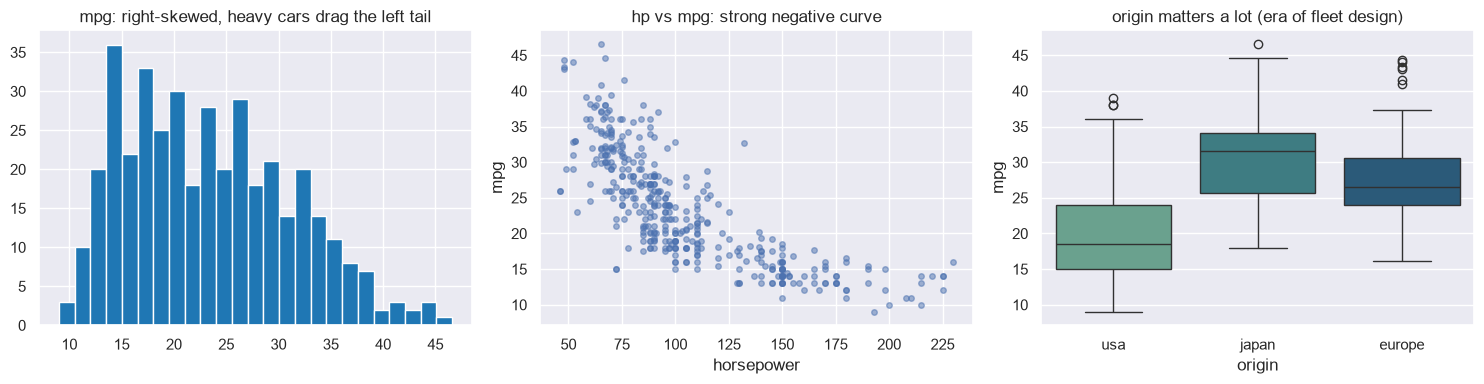

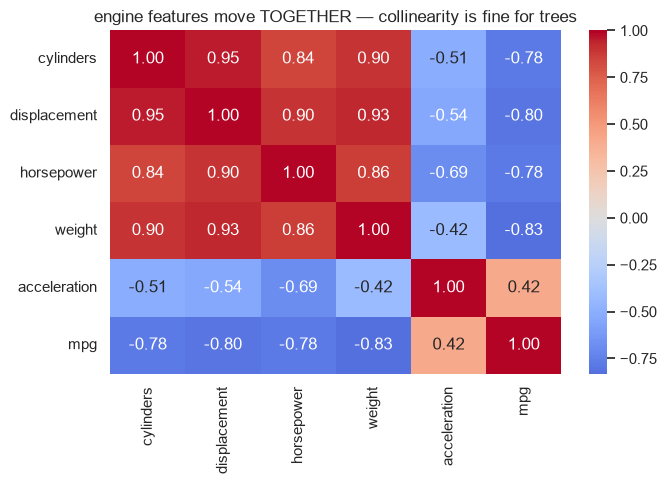

In [2]:
print("missing values:\n", df.isna().sum()[lambda s: s > 0])   # horsepower: 6 NaNs
print("\ndtypes:\n", df.dtypes)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["mpg"], bins=25, color="tab:blue", edgecolor="white")
axes[0].set_title("mpg: right-skewed, heavy cars drag the left tail")

axes[1].scatter(df["horsepower"], df["mpg"], s=16, alpha=0.5)
axes[1].set_xlabel("horsepower"); axes[1].set_ylabel("mpg")
axes[1].set_title("hp vs mpg: strong negative curve")

sns.boxplot(data=df, x="origin", y="mpg", hue="origin", palette="crest",
            legend=False, ax=axes[2])
axes[2].set_title("origin matters a lot (era of fleet design)")
plt.tight_layout(); plt.show()

num_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols + ["mpg"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("engine features move TOGETHER - collinearity is fine for trees")
plt.tight_layout(); plt.show()
# 💡 Linear models suffer under multicollinearity; boosted stumps simply pick whichever
#    of the correlated trio splits best first - interpret importances with that in mind.
# ⚠️ We drop `name` (model year + make): near-unique text column, pure leakage risk
#    and no generalisable signal for a tree stump.

### 2. Processing - split FIRST, then touch anything

- Impute `horsepower` with the **training-set median** (robust to the skewed hp
  distribution; fitting the median on all rows would leak test information).
- One-hot `origin` (`pd.get_dummies`) - categories are fixed and known, so encoding
  before the split leaks nothing; the *median*, unlike categories, must come from train.

In [3]:
df_model = df.drop(columns=["name"]).copy()              # drop free-text identifier

X = df_model.drop(columns=["mpg"])
y = df_model["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42,
)

hp_median = X_train["horsepower"].median()               # TRAIN median only
X_train["horsepower"] = X_train["horsepower"].fillna(hp_median)
X_test["horsepower"] = X_test["horsepower"].fillna(hp_median)   # same value on test!
print(f"train-median horsepower used for imputation: {hp_median}")

X_train = pd.get_dummies(X_train, columns=["origin"])    # one-hot encode categoricals
X_test = pd.get_dummies(X_test, columns=["origin"])
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
print(f"feature matrix: {X_train.shape[1]} columns:", list(X_train.columns))

train-median horsepower used for imputation: 92.0
feature matrix: 9 columns: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_europe', 'origin_japan', 'origin_usa']


### 3. Baselines and the rounds curve (no `staged_predict` here!)

⚠️ Reminder from notebook 02: AdaBoost **regressor** has no staged API, so we fit one
model per size and trace test R² / MAE across sizes.

n= 25 | R²=0.830 | MAE=2.37
n= 50 | R²=0.831 | MAE=2.37


n=100 | R²=0.834 | MAE=2.42


n=200 | R²=0.834 | MAE=2.43


n=300 | R²=0.834 | MAE=2.43

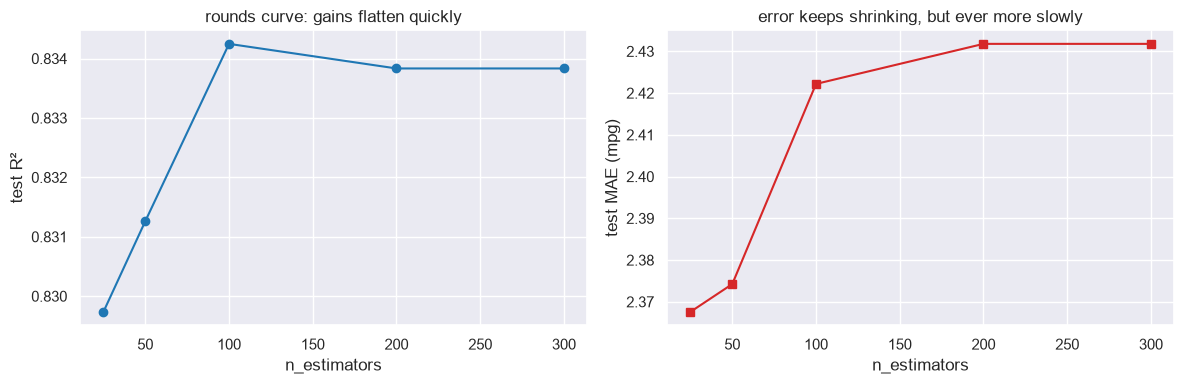

Dummy (mean)           R²=-0.004  MAE=5.96
Single depth-2 tree    R²=0.678  MAE=3.10
AdaBoost default (50)  R²=0.823  MAE=2.53


In [4]:
def score_on(model):
    """Fit on train, return test metrics dict."""
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "R²": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
    }

results = {}
results["Dummy (mean)"] = score_on(DummyRegressor())
results["Single depth-2 tree"] = score_on(DecisionTreeRegressor(max_depth=2))
results["AdaBoost default (50)"] = score_on(
    AdaBoostRegressor(DecisionTreeRegressor(max_depth=2), random_state=42))

n_grid = [25, 50, 100, 200, 300]                 # separate fits per point - by hand
curve_r2, curve_mae = [], []
for n_est in n_grid:
    m = AdaBoostRegressor(DecisionTreeRegressor(max_depth=2), n_estimators=n_est,
                          learning_rate=0.5, random_state=42).fit(X_train, y_train)
    curve_r2.append(r2_score(y_test, m.predict(X_test)))
    curve_mae.append(mean_absolute_error(y_test, m.predict(X_test)))
    print(f"n={n_est:>3} | R²={curve_r2[-1]:.3f} | MAE={curve_mae[-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_grid, curve_r2, marker="o", color="tab:blue")
axes[0].set_xlabel("n_estimators"); axes[0].set_ylabel("test R²")
axes[0].set_title("rounds curve: gains flatten quickly")
axes[1].plot(n_grid, curve_mae, marker="s", color="tab:red")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("test MAE (mpg)")
axes[1].set_title("error keeps shrinking, but ever more slowly")
plt.tight_layout(); plt.show()

for name, met in results.items():
    print(f"{name:<22} R²={met['R²']:.3f}  MAE={met['MAE']:.2f}")

### 4. Small tuning pass + cross-validation honesty check

We tune with 5-fold CV **on the training set only** (scikit handles the folds),
then report ONE final number on the untouched test set.

In [5]:
param_grid = {
    "estimator__max_depth": [2, 3],
    "learning_rate": [0.05, 0.3, 1.0],
    "loss": ["linear", "exponential"],
}
search = GridSearchCV(
    AdaBoostRegressor(DecisionTreeRegressor(random_state=42),
                      n_estimators=200, random_state=42),
    param_grid, cv=5, scoring="r2", n_jobs=-1,
).fit(X_train, y_train)
print("best params:", search.best_params_)
cv_best = cross_val_score(search.best_estimator_, X_train, y_train, cv=5, scoring="r2")

final_ada = search.best_estimator_
pred_test = final_ada.predict(X_test)
print(f"train CV R² : {cv_best.mean():.3f} ± {cv_best.std():.3f}")
print(f"test  R²/MAE: {r2_score(y_test, pred_test):.3f} / "
      f"{mean_absolute_error(y_test, pred_test):.2f}")
print(f"rounds survived: {len(final_ada.estimators_)}/{200}")

best params: {'estimator__max_depth': 3, 'learning_rate': 0.05, 'loss': 'exponential'}


train CV R² : 0.815 ± 0.047
test  R²/MAE: 0.862 / 2.14
rounds survived: 200/200


### 5. What drives fuel economy? Importances + residual diagnostics


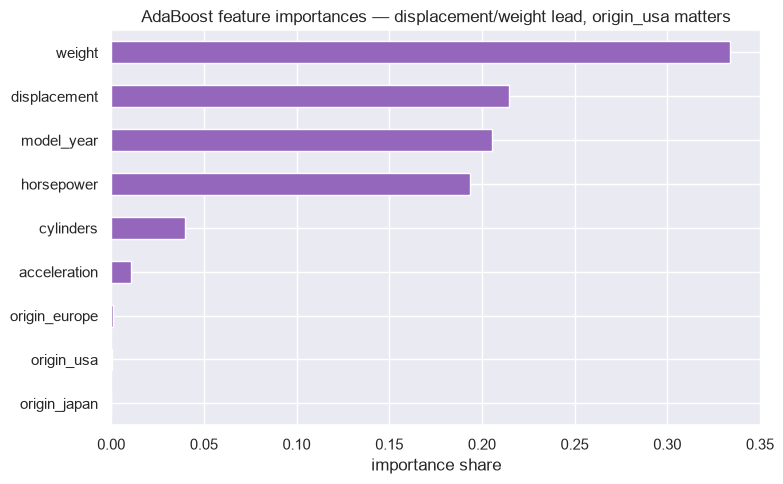

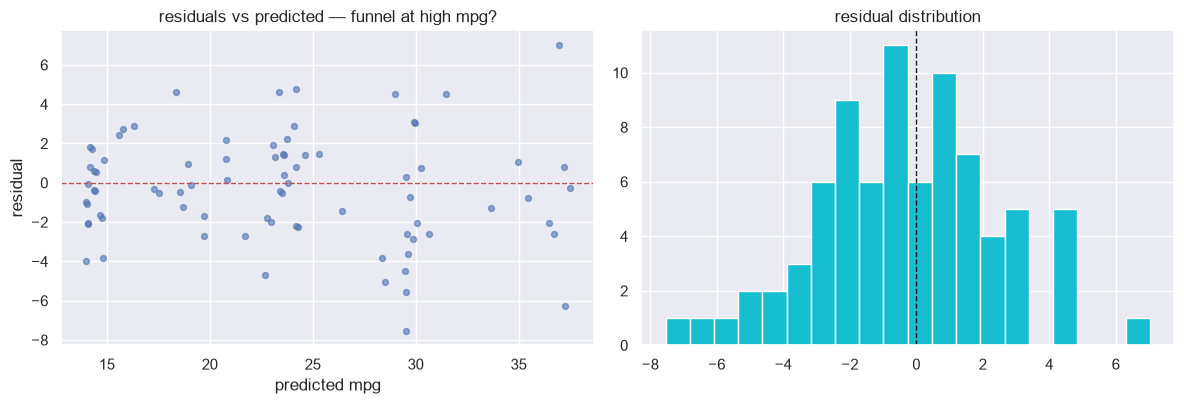

5 worst predictions (residual, mpg):
 {389: 7.5, 394: 7.0, 377: 6.3, 373: 5.5, 341: 5.0}


In [6]:
imp = pd.Series(final_ada.feature_importances_, index=X_train.columns).sort_values()
plt.figure(figsize=(8, 5))
imp.plot.barh(color="tab:purple")
plt.title("AdaBoost feature importances - displacement/weight lead, origin_usa matters")
plt.xlabel("importance share")
plt.tight_layout(); plt.show()
# 💡 Correlated trio (displacement/weight/horsepower) SPLITS the credit between them;
#    read them as one 'engine size' story rather than three independent effects.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
resid = y_test - pred_test
axes[0].scatter(pred_test, resid, s=18, alpha=0.6)
axes[0].axhline(0, color="r", ls="--", lw=1)
axes[0].set_xlabel("predicted mpg"); axes[0].set_ylabel("residual")
axes[0].set_title("residuals vs predicted - funnel at high mpg?")
axes[1].hist(resid, bins=20, color="tab:cyan", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("residual distribution")
plt.tight_layout(); plt.show()

worst = resid.abs().sort_values(ascending=False).head(5)
print("5 worst predictions (residual, mpg):\n", worst.round(1).to_dict())

### 6. Findings & limitations

**Findings**
- Engine mass/displacement dominates; `origin` adds real signal beyond specs -
  US-market cars of this era were systematically thirstier at equal horsepower.
- Boosting beats both the dummy and a single depth-2 tree; most gain arrives by
  ~50 rounds, so the extra trees mostly polish.
- Residual spread widens for efficient cars: the model is sharpest on typical
  gas-guzzlers, weakest on the eco fringe.

**Limitations**
- Data covers 1970-1982 technology only - zero transfer to modern hybrids/EVs.
- Median-imputed horsepower (6 cars) is a pragmatic patch, not ground truth.
- ⚠️ Tree ensembles cannot extrapolate: a hypothetical 40-mpg-tech car would get
  predictions clamped near the training range's edge.
- Multicollinearity blurs per-feature importance attribution.

### Summary takeaways

- Split → train-median imputation → one-hot: the order protects against leakage.
- No staged API for AdaBoost regressors; build curves with explicit refits.
- Importances of collinear features should be read as GROUPS, not individuals.
- Always end by looking at the WORST predictions - they define where the model
  cannot be trusted.